<a href="https://colab.research.google.com/github/anojan7/-northstar-analytics-UWL/blob/main/02_sql_in_r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 - Install and load libraries
install.packages("sqldf")
install.packages("readr")

library(sqldf)
library(readr)

print("Libraries ready!")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



[1] "Libraries ready!"


In [6]:
# Cell 2 - Upload files directly in R session
# This will show a file chooser - select all 9 CSVs

upload_files <- function() {
  system("pip install -q colab 2>/dev/null")

  files_to_upload <- c("customers.csv", "drivers.csv", "vehicles.csv",
                        "orders.csv", "deliveries.csv", "incidents.csv",
                        "complaints.csv", "app_events.csv", "hubs.csv")

  cat("Please upload your CSV files using the folder icon on the left sidebar\n")
  cat("Click the Files icon → Upload → select all 9 CSVs\n")
}

upload_files()

Please upload your CSV files using the folder icon on the left sidebar
Click the Files icon → Upload → select all 9 CSVs


In [7]:
# Load files directly
customers  <- read.csv("customers.csv")
drivers    <- read.csv("drivers.csv")
vehicles   <- read.csv("vehicles.csv")
orders     <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
incidents  <- read.csv("incidents.csv")
complaints <- read.csv("complaints.csv")
app_events <- read.csv("app_events.csv")
hubs       <- read.csv("hubs.csv")

cat("customers: ",  nrow(customers),  "rows\n")
cat("orders: ",     nrow(orders),     "rows\n")
cat("deliveries: ", nrow(deliveries), "rows\n")
cat("Done!\n")

customers:  650 rows
orders:  1250 rows
deliveries:  950 rows
Done!


In [8]:
# Cell 3 - SQL Query 1: Late Delivery Rate by Zone
# This joins orders and deliveries to calculate failure rates per zone

query1 <- sqldf("
  SELECT
    o.pickup_zone,
    COUNT(d.delivery_id)                                    AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1
             ELSE 0 END)                                    AS delayed,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1
             ELSE 0 END)                                    AS failed,
    SUM(CASE WHEN d.delivery_status != 'OnTime' THEN 1
             ELSE 0 END)                                    AS total_issues,
    ROUND(SUM(CASE WHEN d.delivery_status != 'OnTime'
                   THEN 1 ELSE 0 END) * 100.0 /
                   COUNT(d.delivery_id), 1)                 AS issue_rate_pct
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY issue_rate_pct DESC
")

print("Query 1: Delivery Issue Rate by Zone")
print(query1)

[1] "Query 1: Delivery Issue Rate by Zone"
   pickup_zone total_deliveries delayed failed total_issues issue_rate_pct
1          Ctr               64      24     11           35           54.7
2      CENTRAL               55      16     11           27           49.1
3      Central               55      11     11           22           40.0
4    RiverSide               66      12     14           26           39.4
5      Airport               67      18      8           26           38.8
6      AIRPORT               46      13      4           17           37.0
7        North               37       6      7           13           35.1
8        NORTH               46       9      7           16           34.8
9    Riverside               53      13      4           17           32.1
10        East               78      17      8           25           32.1
11        EAST               78      14     11           25           32.1
12        WEST               63      13      7           

In [9]:
# Cell 3 - Fix Zone Names in R first

zone_map <- c(
  'NORTH'     = 'North',
  'north'     = 'North',
  'SOUTH'     = 'South',
  'EAST'      = 'East',
  'WEST'      = 'West',
  'CENTRAL'   = 'Central',
  'Ctr'       = 'Central',
  'AIRPORT'   = 'Airport',
  'RiverSide' = 'Riverside',
  'RIVERSIDE' = 'Riverside'
)

# Function to clean a zone column
clean_zone <- function(zone_col) {
  cleaned <- zone_map[zone_col]
  cleaned[is.na(cleaned)] <- zone_col[is.na(cleaned)]
  return(cleaned)
}

# Apply to all zone columns
orders$pickup_zone      <- clean_zone(orders$pickup_zone)
orders$dropoff_zone     <- clean_zone(orders$dropoff_zone)
customers$home_zone     <- clean_zone(customers$home_zone)
drivers$base_zone       <- clean_zone(drivers$base_zone)
vehicles$assigned_zone  <- clean_zone(vehicles$assigned_zone)
app_events$zone_context <- clean_zone(app_events$zone_context)

# Verify
cat("Unique zones after cleaning:\n")
print(sort(unique(orders$pickup_zone)))

Unique zones after cleaning:
[1] "Airport"   "Central"   "East"      "North"     "Riverside" "South"    
[7] "West"     


In [10]:
# Cell 4 - SQL Query 1: Late Delivery Rate by Zone

query1 <- sqldf("
  SELECT
    o.pickup_zone,
    COUNT(d.delivery_id)                                    AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1
             ELSE 0 END)                                    AS delayed,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1
             ELSE 0 END)                                    AS failed,
    ROUND(SUM(CASE WHEN d.delivery_status != 'OnTime'
                   THEN 1 ELSE 0 END) * 100.0 /
                   COUNT(d.delivery_id), 1)                 AS issue_rate_pct
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY issue_rate_pct DESC
")

print("Query 1: Delivery Issue Rate by Zone")
print(query1)

[1] "Query 1: Delivery Issue Rate by Zone"
  pickup_zone total_deliveries delayed failed issue_rate_pct
1     Central              174      51     33           48.3
2     Airport              113      31     12           38.1
3   Riverside              119      25     18           36.1
4        East              156      31     19           32.1
5       North              135      21     22           31.9
6        West              114      21     14           30.7
7       South              139      22     14           25.9


In [11]:
# Cell 5 - SQL Query 2: Driver Performance Analysis?

query2 <- sqldf("
  SELECT
    d.driver_id,
    d.employment_type,
    d.training_score,
    d.driver_rating,
    COUNT(del.delivery_id)                                    AS total_deliveries,
    SUM(del.manual_route_override_count)                      AS total_overrides,
    ROUND(SUM(del.manual_route_override_count) * 1.0 /
          COUNT(del.delivery_id), 2)                          AS overrides_per_delivery,
    SUM(CASE WHEN del.delivery_status != 'OnTime'
             THEN 1 ELSE 0 END)                               AS problem_deliveries,
    ROUND(SUM(CASE WHEN del.delivery_status != 'OnTime'
                   THEN 1 ELSE 0 END) * 100.0 /
          COUNT(del.delivery_id), 1)                          AS problem_rate_pct
  FROM drivers d
  JOIN deliveries del ON d.driver_id = del.driver_id
  GROUP BY d.driver_id, d.employment_type,
           d.training_score, d.driver_rating
  HAVING COUNT(del.delivery_id) >= 3
  ORDER BY overrides_per_delivery DESC
  LIMIT 10
")

print("Query 2: Top 10 Drivers by Route Override Rate")
print(query2)

[1] "Query 2: Top 10 Drivers by Route Override Rate"
   driver_id employment_type training_score driver_rating total_deliveries
1       D127        FullTime           61.5          4.19                6
2       D062        FullTime           62.4          4.48                3
3       D069        PartTime           61.5          5.00                7
4       D085        PartTime           84.5          4.11                4
5       D105        Contract           82.0          3.71                7
6       D124        FullTime           70.6          3.78                4
7       D130        FullTime           71.2          3.64                8
8       D139        FullTime           71.4          4.99                5
9       D028        FullTime           83.0          4.07                7
10      D027        PartTime           74.3          3.70                6
   total_overrides overrides_per_delivery problem_deliveries problem_rate_pct
1               17                   2.83   

In [12]:
# Cell 6 - SQL Query 3: Hub Performance with Complaints


query3 <- sqldf("
  SELECT
    h.hub_name,
    h.zone,
    h.hub_type,
    COUNT(DISTINCT del.delivery_id)                           AS total_deliveries,
    SUM(CASE WHEN del.delivery_status = 'Failed'
             THEN 1 ELSE 0 END)                               AS failed_deliveries,
    ROUND(SUM(CASE WHEN del.delivery_status = 'Failed'
                   THEN 1 ELSE 0 END) * 100.0 /
          COUNT(DISTINCT del.delivery_id), 1)                 AS failure_rate_pct,
    COUNT(DISTINCT c.complaint_id)                            AS total_complaints,
    ROUND(AVG(c.compensation_amount), 2)                      AS avg_compensation
  FROM hubs h
  JOIN deliveries del ON h.hub_id = del.hub_id
  LEFT JOIN complaints c ON del.order_id = c.order_id
  GROUP BY h.hub_id, h.hub_name, h.zone, h.hub_type
  ORDER BY failure_rate_pct DESC
")

print("Query 3: Hub Performance with Complaints")
print(query3)

[1] "Query 3: Hub Performance with Complaints"
        hub_name      zone  hub_type total_deliveries failed_deliveries
1  Midtown Relay   Central  Charging              128                27
2   Central Core   Central   Control              115                23
3    Airport Hub   Airport  Dispatch              104                15
4 North Exchange     North  Dispatch              136                18
5      West Gate      West  Dispatch              127                16
6  Riverside Hub Riverside Warehouse              115                14
7     South Link     South  Dispatch              106                10
8      East Dock      East Warehouse              119                11
  failure_rate_pct total_complaints avg_compensation
1             21.1               35            21.24
2             20.0               30            24.74
3             14.4               23            21.32
4             13.2               32            17.96
5             12.6               28     

In [13]:
# Cell 7 - SQL Query 4: Performance by Service Type

query4 <- sqldf("
  SELECT
    o.service_type,
    COUNT(d.delivery_id)                                    AS total_orders,
    SUM(CASE WHEN d.delivery_status = 'OnTime'
             THEN 1 ELSE 0 END)                             AS on_time,
    SUM(CASE WHEN d.delivery_status = 'Delayed'
             THEN 1 ELSE 0 END)                             AS delayed,
    SUM(CASE WHEN d.delivery_status = 'Failed'
             THEN 1 ELSE 0 END)                             AS failed,
    ROUND(AVG(d.customer_rating_post_delivery), 2)          AS avg_rating,
    ROUND(AVG(o.order_value), 2)                            AS avg_order_value,
    ROUND(SUM(CASE WHEN d.delivery_status != 'OnTime'
                   THEN 1 ELSE 0 END) * 100.0 /
          COUNT(d.delivery_id), 1)                          AS issue_rate_pct
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type
  ORDER BY issue_rate_pct DESC
")

print("Query 4: Performance by Service Type")
print(query4)

[1] "Query 4: Performance by Service Type"
  service_type total_orders on_time delayed failed avg_rating avg_order_value
1     Business          126      73      28     25       3.85           97.45
2      Medical          108      70      22     16       3.84           86.53
3       Retail          224     146      50     28       3.87           86.81
4    Passenger          262     171      53     38       3.85           97.19
5       Parcel          230     156      49     25       3.90           90.15
  issue_rate_pct
1           42.1
2           35.2
3           34.8
4           34.7
5           32.2


In [14]:
# Cell 8 - Query Optimisation Discussion
# UNOPTIMISED version - no filtering, processes all rows
system.time({
  unoptimised <- sqldf("
    SELECT o.pickup_zone,
           COUNT(*) as total,
           AVG(d.customer_rating_post_delivery) as avg_rating
    FROM orders o
    JOIN deliveries d ON o.order_id = d.order_id
    GROUP BY o.pickup_zone
  ")
})

# OPTIMISED version - filter early, reduce rows before joining
system.time({
  optimised <- sqldf("
    SELECT o.pickup_zone,
           COUNT(*) as total,
           AVG(d.customer_rating_post_delivery) as avg_rating
    FROM orders o
    JOIN deliveries d ON o.order_id = d.order_id
    WHERE d.delivery_status != 'OnTime'
    AND o.order_value > 0
    GROUP BY o.pickup_zone
    ORDER BY avg_rating ASC
    LIMIT 10
  ")
})

print("Optimised query results:")
print(optimised)

cat("\nOptimisation techniques applied:\n")
cat("1. WHERE clause filters rows BEFORE grouping - reduces data processed\n")
cat("2. LIMIT 10 stops processing after finding top 10 results\n")
cat("3. ORDER BY applied after filtering - sorts smaller dataset\n")
cat("4. SELECT only needed columns - avoids fetching unnecessary data\n")

   user  system elapsed 
  0.084   0.008   0.099 

   user  system elapsed 
  0.078   0.011   0.102 

[1] "Optimised query results:"
  pickup_zone total avg_rating
1     Central    84   2.881341
2        West    35   3.006286
3       North    43   3.090698
4        East    50   3.116000
5       South    36   3.156286
6   Riverside    43   3.167209
7     Airport    43   3.406500

Optimisation techniques applied:
1. WHERE clause filters rows BEFORE grouping - reduces data processed
2. LIMIT 10 stops processing after finding top 10 results
3. ORDER BY applied after filtering - sorts smaller dataset
4. SELECT only needed columns - avoids fetching unnecessary data


In [15]:
# Cell 9 - Install and load ggplot2
install.packages("ggplot2")
install.packages("dplyr")
library(ggplot2)
library(dplyr)

cat("ggplot2 ready!\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




ggplot2 ready!


In [16]:
# Cell 10 - R Analytics Visualisations using ggplot2

# prepare the data using dplyr
zone_stats <- orders %>%
  inner_join(deliveries, by = "order_id") %>%
  group_by(pickup_zone) %>%
  summarise(
    total        = n(),
    failed       = sum(delivery_status == "Failed"),
    delayed      = sum(delivery_status == "Delayed"),
    issue_rate   = round((failed + delayed) / total * 100, 1),
    avg_rating   = round(mean(customer_rating_post_delivery, na.rm=TRUE), 2)
  ) %>%
  arrange(desc(issue_rate))

print("Zone stats prepared:")
print(zone_stats)

[1] "Zone stats prepared:"
# A tibble: 7 × 6
  pickup_zone total failed delayed issue_rate avg_rating
  <chr>       <int>  <int>   <int>      <dbl>      <dbl>
1 Central       174     33      51       48.3       3.55
2 Airport       113     12      31       38.1       3.98
3 Riverside     119     18      25       36.1       3.86
4 East          156     19      31       32.1       3.91
5 North         135     22      21       31.9       3.9 
6 West          114     14      21       30.7       3.9 
7 South         139     14      22       25.9       4.05


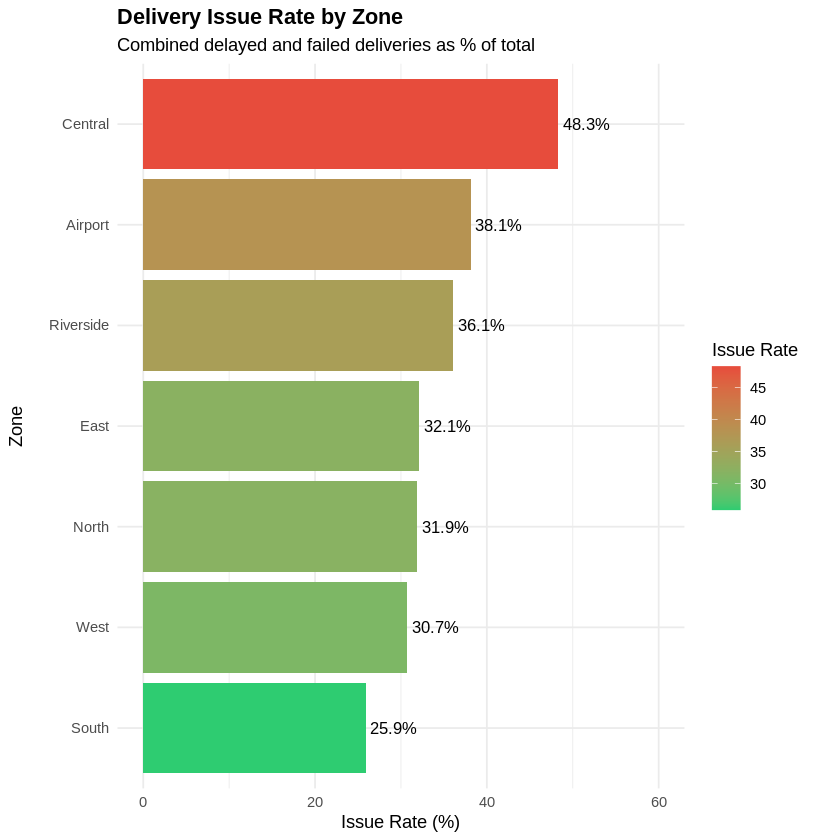

In [17]:
# Cell 11 - Chart 1: Issue Rate by Zone
chart1 <- ggplot(zone_stats, aes(x = reorder(pickup_zone, issue_rate),
                                  y = issue_rate,
                                  fill = issue_rate)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(issue_rate, "%")),
            hjust = -0.1, size = 3.5) +
  scale_fill_gradient(low = "#2ecc71", high = "#e74c3c") +
  coord_flip() +
  labs(
    title    = "Delivery Issue Rate by Zone",
    subtitle = "Combined delayed and failed deliveries as % of total",
    x        = "Zone",
    y        = "Issue Rate (%)",
    fill     = "Issue Rate"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face="bold", size=13)) +
  ylim(0, 60)

print(chart1)

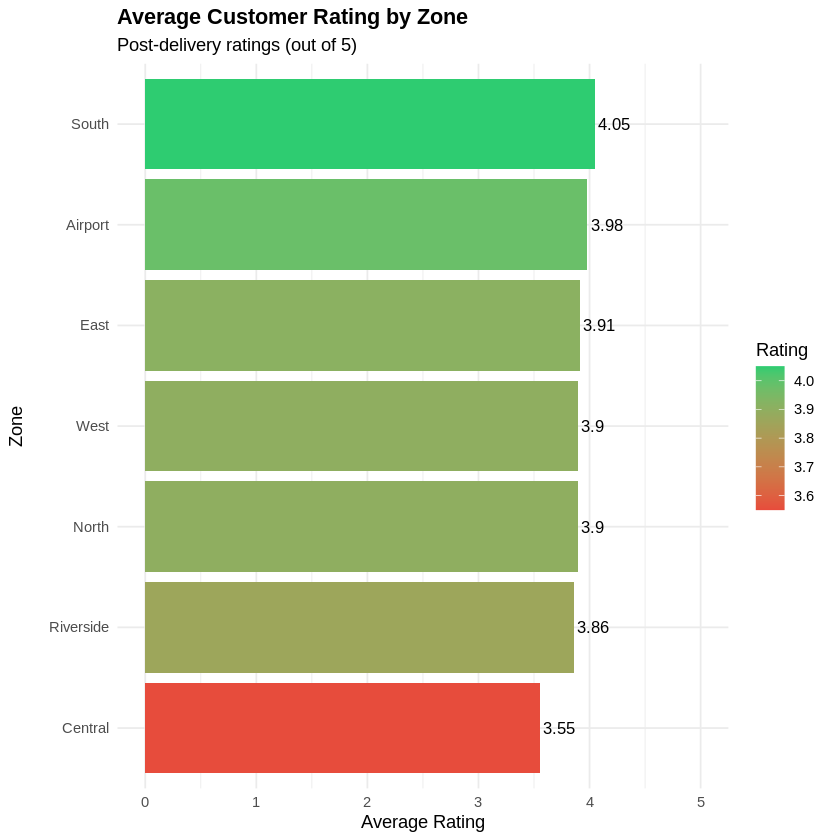

In [18]:
# Cell 12 - Chart 2: Average Customer Rating by Zone
# Shows how customers FEEL about service in each zone

chart2 <- ggplot(zone_stats, aes(x = reorder(pickup_zone, avg_rating),
                                  y = avg_rating,
                                  fill = avg_rating)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = avg_rating),
            hjust = -0.1, size = 3.5) +
  scale_fill_gradient(low = "#e74c3c", high = "#2ecc71") +
  coord_flip() +
  labs(
    title    = "Average Customer Rating by Zone",
    subtitle = "Post-delivery ratings (out of 5)",
    x        = "Zone",
    y        = "Average Rating",
    fill     = "Rating"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face="bold", size=13)) +
  ylim(0, 5)

print(chart2)

[1] "Combined data:"
# A tibble: 7 × 7
  pickup_zone total failed delayed issue_rate avg_rating total_complaints
  <chr>       <int>  <int>   <int>      <dbl>      <dbl>            <int>
1 Central       174     33      51       48.3       3.55               60
2 Airport       113     12      31       38.1       3.98               32
3 Riverside     119     18      25       36.1       3.86               45
4 East          156     19      31       32.1       3.91               50
5 North         135     22      21       31.9       3.9                53
6 West          114     14      21       30.7       3.9                34
7 South         139     14      22       25.9       4.05               46


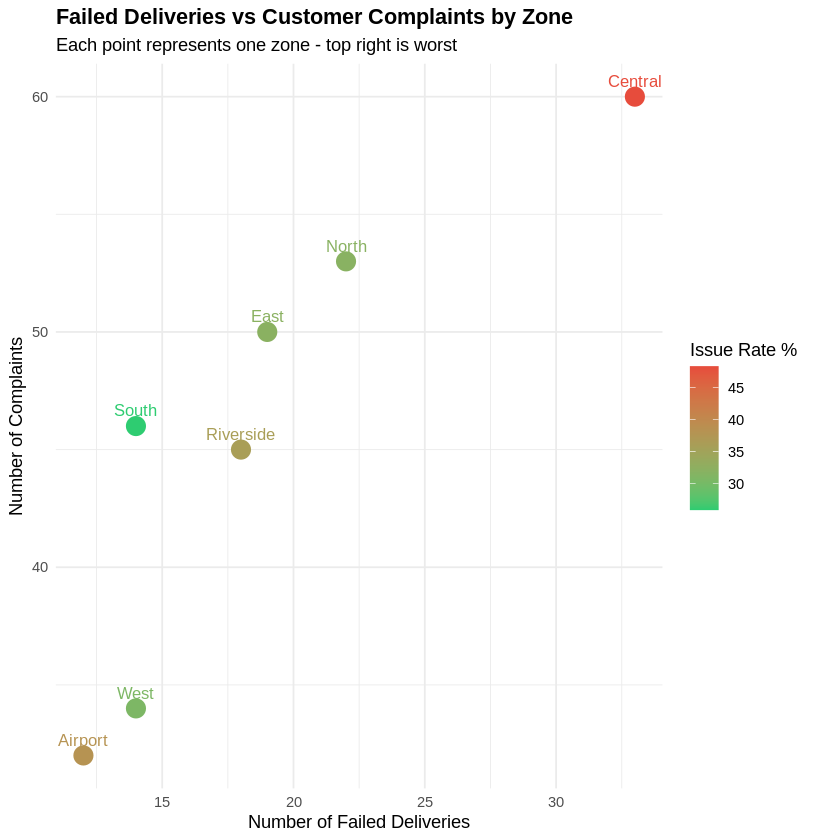

In [19]:
# Cell 13 - Chart 3: Failed Deliveries vs Complaints by Zone
# Shows relationship between operational failures and customer complaints

# Prepare complaints data by zone
complaint_zone <- orders %>%
  inner_join(complaints, by = "order_id") %>%
  group_by(pickup_zone) %>%
  summarise(total_complaints = n())

# Combine with zone stats
combined <- zone_stats %>%
  inner_join(complaint_zone, by = "pickup_zone")

print("Combined data:")
print(combined)

# Chart
chart3 <- ggplot(combined, aes(x = failed, y = total_complaints,
                                label = pickup_zone,
                                color = issue_rate)) +
  geom_point(size = 5) +
  geom_text(vjust = -0.8, size = 3.5) +
  scale_color_gradient(low = "#2ecc71", high = "#e74c3c") +
  labs(
    title    = "Failed Deliveries vs Customer Complaints by Zone",
    subtitle = "Each point represents one zone - top right is worst",
    x        = "Number of Failed Deliveries",
    y        = "Number of Complaints",
    color    = "Issue Rate %"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face="bold", size=13))

print(chart3)